In [292]:
import math
import random

# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa
from mesa.space import SingleGrid
import matplotlib.pyplot as plt

class CellAgent(mesa.Agent):
    def __init__(self, model, taxa=0.0):
        super().__init__(model)
        self.taxa = taxa
        self.proxima_taxa = taxa

    def prepare_update(self):
        neighbors = self.model.grid.get_neighbors(
            self.pos, moore=False, include_center=False
        )

        neighbor_sum = sum(neighbor.taxa for neighbor in neighbors)

        laplacian = neighbor_sum - 4 * self.taxa

        self.proxima_taxa = self.taxa + self.model.D_rate * laplacian

    def apply_update(self):
        self.taxa = self.proxima_taxa

class DiffusionModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n=30, rng=None,D_rate=0.20):
        super().__init__(rng=rng)
        self.grid = SingleGrid(n,n, torus=False)
        self.n = n
        self.D_rate = D_rate

        agent_id = 0
        cx, cy = n // 2, n // 2
        for x in range(n):
            for y in range(n):
                if(abs(x) <= 5 and abs(y) <= 5):
                    taxa = 5000.0
                else:
                    taxa = 0.0

                agente = CellAgent(self,taxa)
                self.grid.place_agent(agente, (x, y))
    def step(self):
        for agent in self.agents:
            agent.prepare_update()

        for agent in self.agents:
            agent.apply_update()

    def export(self):
        matrix = np.zeros((self.n, self.n))
        for agent, (x, y) in self.grid.coord_iter():
            if agent:
                matrix[x, y] = agent.taxa
        return matrix


6


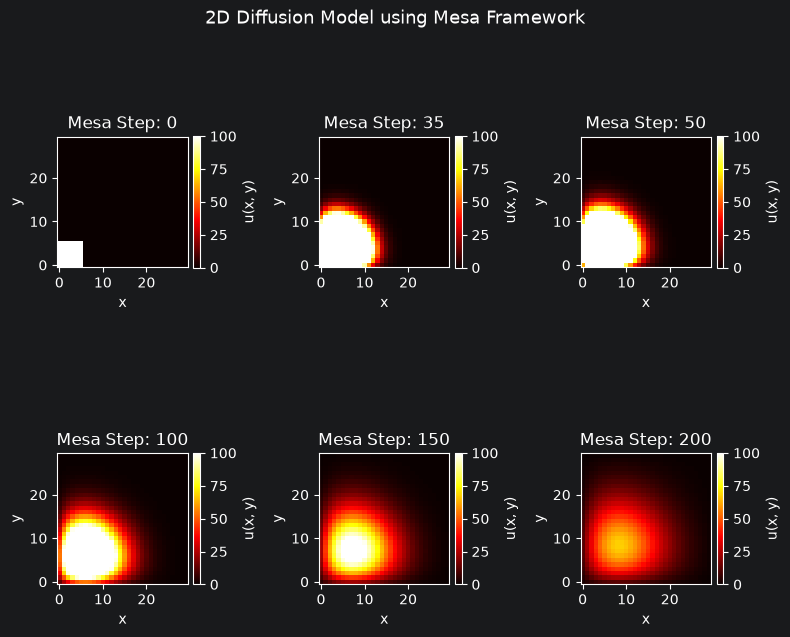

In [293]:

model = DiffusionModel(n=30,D_rate=0.20)

steps_to_capture = [0,35,50,100,150,200]
snapshots = []

for ste in range(201):
    if ste in steps_to_capture:
        snapshots.append((ste, model.export()))
    model.step()

numShapes = len(snapshots)
cols = 3
rows = math.ceil(numShapes/cols)
fig, axes = plt.subplots(rows, cols, figsize=(8, 7))
axes = axes.flatten()
print(len(snapshots))
for idx, (s, data) in enumerate(snapshots):
    im = axes[idx].imshow(data, cmap='hot', origin='lower', vmin=0, vmax=100)
    axes[idx].set_title(f'Mesa Step: {s}')
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('y')
    fig.colorbar(im, ax=axes[idx], label='u(x, y)', fraction=0.046,pad=0.04)
plt.suptitle('2D Diffusion Model using Mesa Framework', fontsize=13)
plt.tight_layout()
plt.show()

np.set_printoptions(precision=1, suppress=True, linewidth=150)


In [245]:
class Gierer_Meninhardt_Model(mesa.Model):
    def __init__(self, n=50, rng=None):
        super().__init__(rng=rng)
        self.grid = SingleGrid(n,n, torus=True)
        self.n = n

        agent_id = 0
        cx, cy = n // 2, n // 2
        for x in range(n):
            for y in range(n):
                qtd_act = 0.5 + random.uniform(-0.02, 0.02)
                qtd_ini = 0.5 + random.uniform(-0.02, 0.02)

                #if(abs(x - cx) <= 2 and abs(y - cy) <= 2):
                #    qtd_act = 2.0
                #else:
                #    qtd_act = 0.0
                #    qtd_ini = 0.00000000000000001

                agente = CellAgent2(model=self, qtd_act = qtd_act, qtd_ini = qtd_ini)
                self.grid.place_agent(agente, (x, y))
    def step(self):
        for agent in self.agents:
            agent.prepare_update()

        for agent in self.agents:
            agent.apply_update()

    def export(self):
        matrix_act = np.zeros((self.n, self.n))
        matrix_ini = np.zeros((self.n, self.n))
        for agent, (x, y) in self.grid.coord_iter():
            if agent:
                matrix_act[x, y] = agent.qtd_act
                matrix_ini[x, y] = agent.qtd_ini
        return matrix_act - matrix_ini

In [283]:
class CellAgent2(mesa.Agent):
    def __init__(self, model,qtd_act, qtd_ini):
        # Listras ?
        #taxa_diff_act = 0.02
        #taxa_diff_ini = 0.02
        #decay_act = 0.01
        #feed = 0.1
        #decay_ini = 0.01

        # Manchas Grades
        taxa_diff_act = 0.001
        taxa_diff_ini = 0.7
        decay_act = 0.7
        feed = 0.2
        decay_ini = 0.01

        # Manchas Pequenas (QUASE)
        #taxa_diff_act = 0.001
        #taxa_diff_ini = 0.005
        #decay_act = 0.6
        #feed = 0.2
        #decay_ini = 0.001

        # Dúvida
        #taxa_diff_act = 0.0005
        #taxa_diff_ini = 0.005
        #decay_act = 1
        #feed = 0.2
        #decay_ini = 0.0001
        self.taxa_dens = 0.01

        super().__init__(model)
        self.taxa_diff_act = taxa_diff_act
        self.decay_act = decay_act
        self.qtd_act = qtd_act
        self.feed_act = feed
        self.proximo_qtd_act = qtd_act
        self.passo_tempo = 0.07
        self.k = 0.01
        self.taxa_diff_ini = taxa_diff_ini
        self.qtd_ini = qtd_ini

        self.proximo_qtd_ini = qtd_ini
        self.decay_ini = decay_ini

    def prepare_update(self):
        neighbors = self.model.grid.get_neighbors(
            self.pos, moore=False, include_center=False
        )
        act_neighbor_sum = sum(neighbor.qtd_act for neighbor in neighbors)
        act_laplacian = act_neighbor_sum - 4 * self.qtd_act
        self.proximo_qtd_act = max(0.0,self.qtd_act + self.passo_tempo *(
                self.taxa_dens * ((self.qtd_act ** 2) / self.qtd_ini) - self.decay_act * self.qtd_act + self.taxa_diff_act * act_laplacian + self.feed_act))

        ini_neighbor_sum = sum(neighbor.qtd_ini for neighbor in neighbors)
        ini_laplacian = ini_neighbor_sum - 4 * self.qtd_ini
        self.proximo_qtd_ini = max(0.0, self.qtd_ini + self.passo_tempo * (
            self.taxa_dens * (self.qtd_act ** 2) - self.decay_ini * self.qtd_ini + self.taxa_diff_ini * ini_laplacian
        ))

    def apply_update(self):
        self.qtd_act = self.proximo_qtd_act
        self.qtd_ini = self.proximo_qtd_ini

6


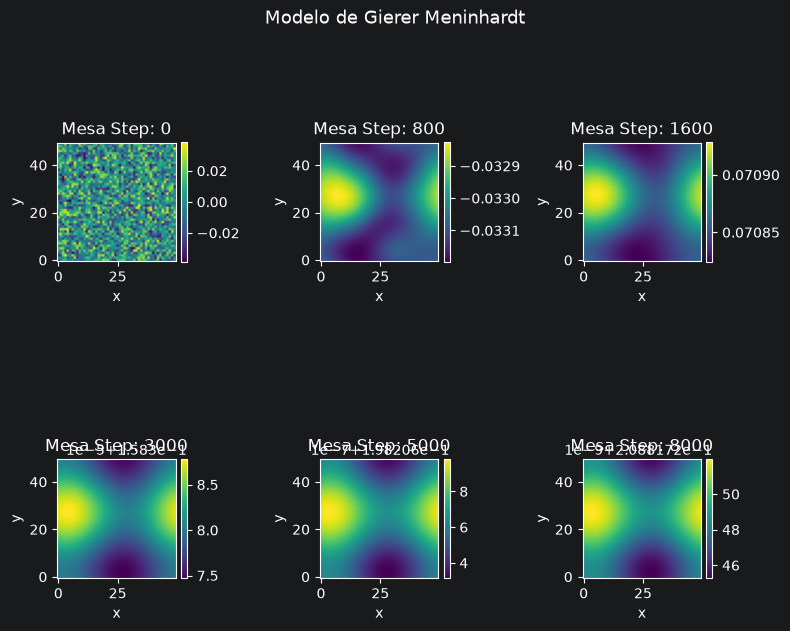

In [284]:
model = Gierer_Meninhardt_Model(n=50)

steps_to_capture = [0, 800, 1600, 3000, 5000, 8000]
snapshots = []

for ste in range(8001):
    if ste in steps_to_capture:
        snapshots.append((ste, model.export()))
    model.step()

numShapes = len(snapshots)
cols = 3
rows = math.ceil(numShapes/cols)
fig, axes = plt.subplots(rows, cols, figsize=(8, 7))
axes = axes.flatten()
print(len(snapshots))
for idx, (s, data) in enumerate(snapshots):
    im = axes[idx].imshow(data, cmap='viridis', origin='lower')
    axes[idx].set_title(f'Mesa Step: {s}')
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('y')
    fig.colorbar(im, ax=axes[idx], fraction=0.046,pad=0.04)

plt.suptitle('Modelo de Gierer Meninhardt', fontsize=13)
plt.tight_layout()
plt.show()

np.set_printoptions(precision=1, suppress=True, linewidth=150)

